In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

In [2]:
# Magic command for Colab
%matplotlib inline

In [3]:
class ChurnPredictionModel:
    """
    Advanced Machine Learning Pipeline for Classification.
    Uses Random Forest to predict Customer Churn.
    """

    def __init__(self, train_path: str, test_path: str):
        # UI/UX configuration for plots
        sns.set_theme(style="whitegrid")
        self.colors = ["#2ecc71", "#e74c3c"] # Green for False (Retained), Red for True (Churn)

        # Load Train and Test Data
        try:
            self.train_df = pd.read_csv(train_path)
            self.test_df = pd.read_csv(test_path)
            print(f"[OK] Training Data loaded: {self.train_df.shape[0]} rows.")
            print(f"[OK] Testing Data loaded: {self.test_df.shape[0]} rows.")
        except FileNotFoundError:
            print("[Error] Datasets not found. Please upload both churn-bigml-80.csv and churn-bigml-20.csv.")
            self.train_df = None
            self.test_df = None

        # Initialize the Random Forest Classifier
        self.model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

    def preprocess_data(self):
        """Encodes categorical variables into numerical values for the ML model."""
        if self.train_df is None: return

        print("\n" + "="*35)
        print("=== PHASE 1: DATA PREPROCESSING ===")
        print("="*35)

        self.target_col = 'Churn'

        # Identify categorical columns (text or boolean)
        categorical_cols = self.train_df.select_dtypes(include=['object', 'bool']).columns

        # Apply Label Encoding
        # We fit the encoder on combined data to ensure all unique labels are captured
        for col in categorical_cols:
            le = LabelEncoder()
            combined_data = pd.concat([self.train_df[col], self.test_df[col]], axis=0).astype(str)
            le.fit(combined_data)

            self.train_df[col] = le.transform(self.train_df[col].astype(str))
            self.test_df[col] = le.transform(self.test_df[col].astype(str))

        # Separate Features (X) and Target (y)
        self.X_train = self.train_df.drop(columns=[self.target_col])
        self.y_train = self.train_df[self.target_col]

        self.X_test = self.test_df.drop(columns=[self.target_col])
        self.y_test = self.test_df[self.target_col]

        print("[*] Categorical encoding successful.")
        print(f"[*] Model is ready to train on {len(self.X_train.columns)} features.")

    def train_and_evaluate(self):
        """Trains the Random Forest model and generates classification metrics."""
        if self.train_df is None: return

        print("\n" + "="*35)
        print("=== PHASE 2: MODEL TRAINING & EVALUATION ===")
        print("="*35)

        # Train the model
        self.model.fit(self.X_train, self.y_train)

        # Make predictions on unseen test data
        self.y_pred = self.model.predict(self.X_test)

        # Display Accuracy
        acc = accuracy_score(self.y_test, self.y_pred)
        print(f"[*] Overall Model Accuracy: {acc * 100:.2f}%\n")

        # Display Classification Report (Precision, Recall, F1-Score)
        print("[*] Detailed Classification Report:")
        # In the encoded target, 0 is Retained (False), 1 is Churn (True)
        report = classification_report(self.y_test, self.y_pred, target_names=['Retained (0)', 'Churn (1)'])
        print(report)

    def plot_confusion_matrix(self):
        """Visualizes the confusion matrix to show True Positives, False Positives, etc."""
        if self.train_df is None: return

        print("\n" + "="*35)
        print("=== PHASE 3: CONFUSION MATRIX VISUALIZATION ===")
        print("="*35)

        cm = confusion_matrix(self.y_test, self.y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted Retained', 'Predicted Churn'],
                    yticklabels=['Actual Retained', 'Actual Churn'],
                    annot_kws={"size": 14})

        plt.title('Random Forest Confusion Matrix', fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self):
        """Plots the top 10 most important features driving customer churn."""
        if self.train_df is None: return

        importances = self.model.feature_importances_
        feature_names = self.X_train.columns

        # Create a DataFrame and sort it
        feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
        plt.title('Top 10 Most Important Features for Churn Prediction', fontsize=14, fontweight='bold')
        plt.xlabel('Relative Importance (Gini)', fontsize=12)
        plt.ylabel('Feature Name', fontsize=12)
        plt.tight_layout()
        plt.show()

In [5]:
# Initialize and execute Classification pipeline
churn_model = ChurnPredictionModel('churn-bigml-80.csv', 'churn-bigml-20.csv')

[OK] Training Data loaded: 2666 rows.
[OK] Testing Data loaded: 667 rows.


In [6]:
churn_model.preprocess_data()


=== PHASE 1: DATA PREPROCESSING ===
[*] Categorical encoding successful.
[*] Model is ready to train on 19 features.


In [13]:
churn_model.train_and_evaluate()


=== PHASE 2: MODEL TRAINING & EVALUATION ===
[*] Overall Model Accuracy: 95.50%

[*] Detailed Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.95      1.00      0.97       572
   Churn (1)       0.99      0.69      0.81        95

    accuracy                           0.96       667
   macro avg       0.97      0.85      0.89       667
weighted avg       0.96      0.96      0.95       667




=== PHASE 3: CONFUSION MATRIX VISUALIZATION ===


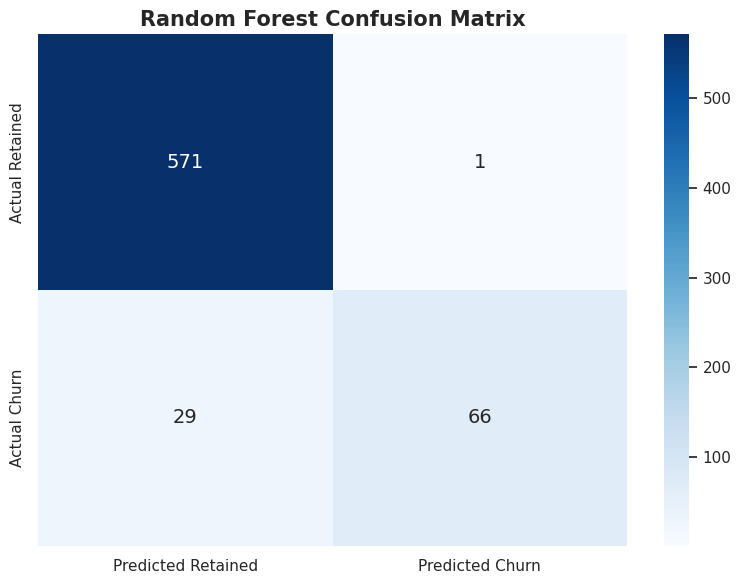

In [10]:
churn_model.plot_confusion_matrix()

/tmp/ipykernel_7017/2615396087.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


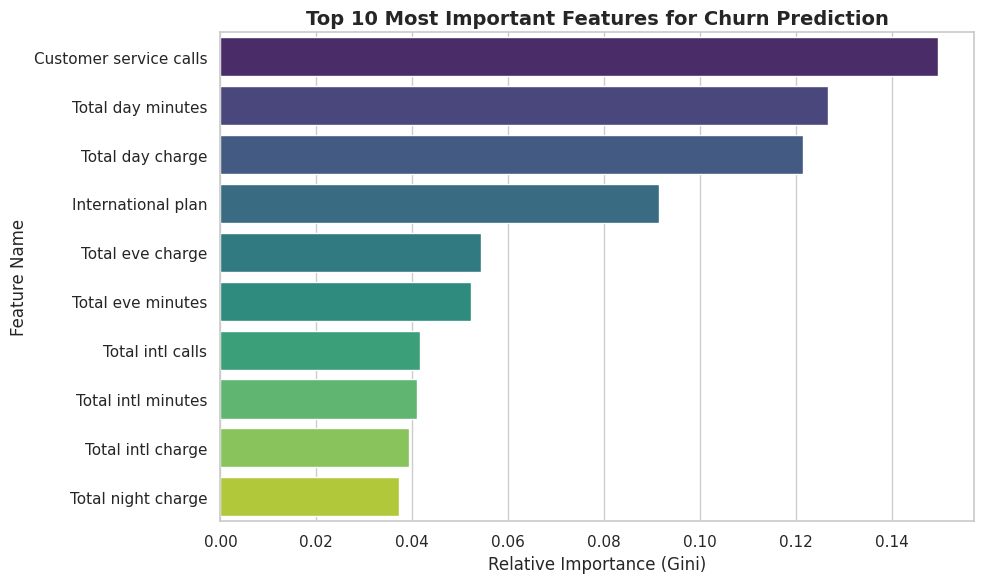

In [11]:
churn_model.plot_feature_importance()